In [1]:
# =========================
# 1️⃣ INSTALL DEPENDENCIES
# =========================
!pip -q install ultralytics opendatasets pandas matplotlib

# =========================
# 2️⃣ IMPORT LIBRARIES
# =========================
import os, shutil, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
from google.colab import files
from PIL import Image

# =========================
# 3️⃣ DOWNLOAD DATASET
# =========================
import opendatasets as od
od.download("https://www.kaggle.com/datasets/jayaprakashpondy/soil-image-dataset?select=Dataset")

DATA_DIR = "/content/soil-image-dataset/Dataset"
YOLO_DIR = "/content/yolov8_dataset"

# =========================
# 4️⃣ PREPARE YOLO DATASET
# =========================
if os.path.exists(YOLO_DIR):
    shutil.rmtree(YOLO_DIR)

train_dir = os.path.join(YOLO_DIR, "train")
val_dir = os.path.join(YOLO_DIR, "val")
os.makedirs(train_dir)
os.makedirs(val_dir)

paths, labels = [], []

for split in os.listdir(DATA_DIR):
    sp = os.path.join(DATA_DIR, split)
    if os.path.isdir(sp):
        for cls in os.listdir(sp):
            cp = os.path.join(sp, cls)
            if os.path.isdir(cp):
                for img in os.listdir(cp):
                    paths.append(os.path.join(cp, img))
                    labels.append(cls)

train_p, val_p, train_l, val_l = train_test_split(paths, labels, test_size=0.2, stratify=labels, random_state=42)
classes = sorted(set(labels))

for c in classes:
    os.makedirs(os.path.join(train_dir, c))
    os.makedirs(os.path.join(val_dir, c))

for p,l in zip(train_p, train_l):
    shutil.copy(p, os.path.join(train_dir, l, os.path.basename(p)))
for p,l in zip(val_p, val_l):
    shutil.copy(p, os.path.join(val_dir, l, os.path.basename(p)))

print("✅ Dataset Ready")

# =========================
# 5️⃣ TRAIN MODEL
# =========================
model = YOLO("yolov8n-cls.pt")
results = model.train(data=YOLO_DIR, epochs=30, imgsz=128)

# =========================
# 6️⃣ LOAD TRAINING HISTORY
# =========================
run_dir = results.save_dir
csv_path = os.path.join(run_dir, "results.csv")

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

print("Available columns:", df.columns.tolist())

epochs = df["epoch"] + 1
accuracy = df["metrics/accuracy_top1"]   # this is validation accuracy
train_loss = df["train/loss"]
val_loss = df["val/loss"]

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, accuracy)
plt.title("Top-1 Accuracy")
plt.xlabel("Epoch")

plt.subplot(1,2,2)
plt.plot(epochs, train_loss, label="Train")
plt.plot(epochs, val_loss, label="Val")
plt.title("Loss")
plt.legend()

plt.show()

# =========================
# 7️⃣ IMAGE INFERENCE
# =========================
print("📤 Upload soil image for prediction")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

best_model_path = os.path.join(run_dir, "weights/best.pt")
model = YOLO(best_model_path)

res = model(img_path)

probs = res[0].probs
cls_id = probs.top1
conf = probs.top1conf.item()
cls_name = model.names[cls_id]

img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")
plt.title(f"{cls_name} | {conf:.2f}")
plt.show()

print("🌱 Predicted Soil:", cls_name)
print("Confidence:", conf)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Adithya811
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jayaprakashpondy/soil-image-dataset


100%|██████████| 144M/144M [00:00<00:00, 1.25GB/s]

✅ Dataset Ready
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov8_dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

KeyboardInterrupt: 

In [ ]:
# =========================
# COLLECT PREDICTIONS ON VALIDATION SET
# =========================

from tqdm import tqdm

model = YOLO(best_model_path)

soil_preds = []
soil_true = []

for cls in os.listdir(val_dir):
    class_folder = os.path.join(val_dir, cls)
    if not os.path.isdir(class_folder):
        continue

    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)

        res = model(img_path, verbose=False)
        pred_id = res[0].probs.top1
        pred_label = model.names[pred_id]

        soil_preds.append(pred_label)
        soil_true.append(cls)

print("✅ Validation predictions collected")

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

✅ Validation predictions collected


📤 Upload soil image for prediction


Saving 238634a32b47d30be5b5fda7a162bc72.jpg to 238634a32b47d30be5b5fda7a162bc72.jpg

image 1/1 /content/238634a32b47d30be5b5fda7a162bc72.jpg: 128x128 Black Soil 1.00, Clay soil 0.00, Alluvial soil 0.00, Red soil 0.00, 12.4ms
Speed: 10.8ms preprocess, 12.4ms inference, 0.1ms postprocess per image at shape (1, 3, 128, 128)


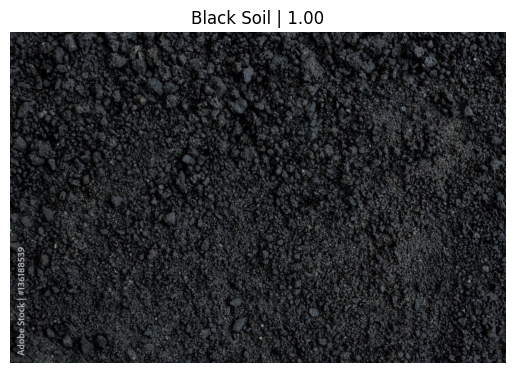

🌱 Predicted Soil: Black Soil
Confidence: 0.9997608065605164


In [ ]:
print("📤 Upload soil image for prediction")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

best_model_path = os.path.join(run_dir, "weights/best.pt")
model = YOLO(best_model_path)

res = model(img_path)

probs = res[0].probs
cls_id = probs.top1
conf = probs.top1conf.item()
cls_name = model.names[cls_id]

img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")
plt.title(f"{cls_name} | {conf:.2f}")
plt.show()

print("🌱 Predicted Soil:", cls_name)
print("Confidence:", conf)

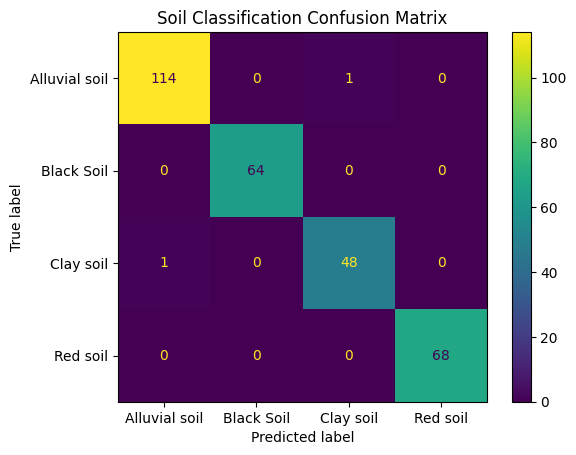

In [ ]:
# =========================
# CONFUSION MATRIX (SOIL)
# =========================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(soil_true, soil_preds, labels=list(model.names.values()))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(model.names.values())
)

disp.plot()
plt.title("Soil Classification Confusion Matrix")
plt.show()